# Retrieving data

In [1]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.4 MB/s eta 0:00:00


In [2]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 11.3 MB/s eta 0:00:00


In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# --- Directory Setup ---
base_dir = ""
fig_dir = os.path.join(base_dir, "figures")
data_dir = os.path.join(base_dir, "data")
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

# Define date range
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = '2010-01-01'


# 1. WTI Crude Oil (Yahoo)
oil = yf.download("CL=F", start="2010-01-01", end=datetime.today().strftime('%Y-%m-%d'), progress=False)
oil.to_csv(os.path.join(data_dir, "oil_prices.csv"))
print("Oil data shape:", oil.shape)
oil['Close'].plot(figsize=(10,6), title="WTI Crude Oil Futures Price")
plt.savefig(os.path.join(fig_dir, "oil_price_time_series.png"))
plt.close()

# 2. Alternative Macro Data via pandas_datareader (FRED)
start = "2010-01-01"
try:
    macro = web.DataReader(['CPIAUCSL', 'FEDFUNDS', 'INDPRO', 'DCOILWTICO'], 'fred', start)
    macro.to_csv(os.path.join(data_dir, "fred_macro.csv"))
    print("Macro data shape:", macro.shape)
    print(macro.tail())
except Exception as e:
    print("pandas_datareader error:", e)
    # Fallback: manual CSV if needed

# 3. Simple EIA example (monthly WTI spot via direct link or expand later)
print("\nData saved. Run EDA next.")

# Quick correlation plot (once more data available)
if not macro.empty:
    sns.heatmap(macro.corr(), annot=True, cmap='coolwarm')
    plt.title("Macro Variables Correlation")
    plt.savefig(os.path.join(fig_dir, "macro_correlation.png"))
    plt.close()



# 1. Financial Data (Yahoo Finance)
print("\n[1/3] Downloading Financial Data (Yahoo Finance)...")
tickers = {
    'WTI_CL': 'CL=F',      # WTI Crude Futures
    'Brent_BZ': 'BZ=F',    # Brent Crude Futures
    'USD_Idx': 'DX-Y.NYB'  # US Dollar Index
}
fin_data = yf.download(list(tickers.values()), start=start_date, end=end_date, progress=False)['Close']
fin_data.rename(columns={v: k for k, v in tickers.items()}, inplace=True)
print(f" -> Financial data downloaded: {fin_data.shape}")

# 2. Macroeconomic Data (FRED)
print("\n[2/3] Downloading Macroeconomic Data (FRED)...")
fred_tickers = {
    'CPIAUCSL': 'CPI',         # Consumer Price Index
    'FEDFUNDS': 'Fed_Funds',   # Federal Funds Rate
    'INDPRO': 'Ind_Prod',      # Industrial Production
    'DCOILWTICO': 'WTI_Spot'   # WTI Spot Price (Daily)
}
try:
    macro_data = web.DataReader(list(fred_tickers.keys()), 'fred', start_date, end_date)
    macro_data.rename(columns=fred_tickers, inplace=True)
    print(f" -> Macro data downloaded: {macro_data.shape}")
except Exception as e:
    print(f" -> ERROR downloading FRED data: {e}")
    print(" -> Ensure 'pandas-datareader' is installed. Proceeding with Yahoo data only.")
    macro_data = pd.DataFrame()

# 3. Aligning to Monthly Frequency
print("\n[3/3] Aligning datasets to Monthly Frequency...")
# Resample daily data to monthly (using last business day)
fin_monthly = fin_data.resample('ME').last()
if not macro_data.empty:
    macro_monthly = macro_data.resample('ME').last()
    # Merge datasets
    df_raw = pd.merge(fin_monthly, macro_monthly, left_index=True, right_index=True, how='left')
else:
    df_raw = fin_monthly

# Drop columns with all NaNs
df_raw.dropna(axis=1, how='all', inplace=True)
print(f" -> Combined Raw Dataset Shape: {df_raw.shape}")
df_raw.to_csv(os.path.join(data_dir, "raw_combined_data.csv"))

print("\n" + "="*60)
print("STEP 5 & 6: DATA PREPROCESSING AND CLEANING")
print("="*60)

df_clean = df_raw.copy()
cleaning_log = []

# A) Extreme Outliers (IQR Method with factor of 3)
print("\n[A] Identifying and Clipping Extreme Outliers (IQR * 3)...")
outlier_count = 0
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR

        # Count outliers before clipping
        outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        if outliers > 0:
            df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)
            outlier_count += outliers
            cleaning_log.append(f"Clipped {outliers} extreme outliers in {col}.")

print(f" -> Total extreme values clipped: {outlier_count}")

# B) Bad or Duplicated Data
print("\n[B] Checking for Duplicated Indices and Chronological Order...")
dupes = df_clean.index.duplicated().sum()
if dupes > 0:
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    cleaning_log.append(f"Removed {dupes} duplicated date indices.")
    print(f" -> Removed {dupes} duplicated indices.")
else:
    print(" -> No duplicated indices found.")

df_clean.sort_index(inplace=True)

# C) Missing Values (Time-based Interpolation + ffill/bfill)
print("\n[C] Handling Missing Values (Interpolation & Forward/Backward Fill)...")
missing_before = df_clean.isnull().sum().sum()
# Time-based interpolation is ideal for financial time series
df_clean.interpolate(method='time', inplace=True, limit_direction='both')
# Fill any remaining edges
df_clean.ffill(inplace=True)
df_clean.bfill(inplace=True)
missing_after = df_clean.isnull().sum().sum()

interpolated_vals = missing_before - missing_after
cleaning_log.append(f"Interpolated/Filled {interpolated_vals} missing values via time-based methods.")
print(f" -> Missing values before: {missing_before}")
print(f" -> Missing values after: {missing_after}")
print(f" -> Total values imputed/filled: {interpolated_vals}")

# Save Cleaned Data
df_clean.to_csv(os.path.join(data_dir, "sterilized_monthly_data.csv"))
print(f"\n -> Sterilized data saved to {data_dir}/sterilized_monthly_data.csv")




Oil data shape: (4164, 5)
Macro data shape: (4373, 4)
            CPIAUCSL  FEDFUNDS  INDPRO  DCOILWTICO
DATE                                              
2026-07-14       NaN       NaN     NaN       80.44
2026-07-15       NaN       NaN     NaN       80.73
2026-07-16       NaN       NaN     NaN       80.03
2026-07-17       NaN       NaN     NaN       83.43
2026-07-20       NaN       NaN     NaN       84.38

Data saved. Run EDA next.

[1/3] Downloading Financial Data (Yahoo Finance)...
 -> Financial data downloaded: (4167, 3)

[2/3] Downloading Macroeconomic Data (FRED)...
 -> Macro data downloaded: (4373, 4)

[3/3] Aligning datasets to Monthly Frequency...
 -> Combined Raw Dataset Shape: (199, 7)

STEP 5 & 6: DATA PREPROCESSING AND CLEANING

[A] Identifying and Clipping Extreme Outliers (IQR * 3)...
 -> Total extreme values clipped: 2

[B] Checking for Duplicated Indices and Chronological Order...
 -> No duplicated indices found.

[C] Handling Missing Values (Interpolation & Forward/B

In [4]:
df_clean.columns

Index(['Brent_BZ', 'WTI_CL', 'USD_Idx', 'CPI', 'Fed_Funds', 'Ind_Prod',
       'WTI_Spot'],
      dtype='object')

Since hmms is not available for google colab, we switched to hmmlearn library for discrete time HMM estimation. Below is a test run of CategoricalHMM estimation, which correspond to DtHMM in hmms library.

In [5]:
from hmmlearn.hmm import CategoricalHMM

model = CategoricalHMM(
    n_components=3,
    n_iter=100
)
data_diff = df_clean['WTI_Spot'].diff()[1:]
##states 1: bull, -1: bear, 0: stagnant
#emit_seq = data_diff.apply(lambda x: 1 if x > 0.2 else (2 if x<-0.2 else 0))
emit_seq = data_diff.apply(lambda x: 1 if x > 0 else 0)


In [6]:
emit_seq

,WTI_Spot
Date,
2010-02-28,1
2010-03-31,1
2010-04-30,1
2010-05-31,0
2010-06-30,1
...,...
2026-03-31,1
2026-04-30,1
2026-05-31,0


In [7]:
emit_seq_2 = emit_seq.to_frame(name='emit_seq')

In [8]:
model.fit(emit_seq_2)

CategoricalHMM(n_components=3, n_features=np.int64(2), n_iter=100,
               random_state=RandomState(MT19937) at 0x7DF3C0520540)

In [9]:
model.emissionprob_

array([[0.57050572, 0.42949428],
       [0.60249941, 0.39750059],
       [0.36248878, 0.63751122]])

In [10]:
model.transmat_

array([[8.05831364e-01, 1.93775831e-01, 3.92804381e-04],
       [1.12187795e-03, 3.98393942e-02, 9.59038728e-01],
       [1.92595605e-01, 4.38531553e-02, 7.63551240e-01]])

In [11]:
model.startprob_

array([9.34281265e-06, 2.30823413e-03, 9.97682423e-01])

In [12]:
states = model.predict(emit_seq_2)

In [57]:
states

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:

from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork



In [14]:
# data: pandas DataFrame
hc = HillClimbSearch(df_clean)

best_model = hc.estimate(scoring_method="bic-g")

print(best_model.edges())

  0%|          | 0/1000000 [00:00<?, ?it/s]

[('Brent_BZ', 'USD_Idx'), ('Brent_BZ', 'Ind_Prod'), ('WTI_CL', 'Brent_BZ'), ('WTI_CL', 'Ind_Prod'), ('USD_Idx', 'Ind_Prod'), ('CPI', 'Fed_Funds'), ('CPI', 'USD_Idx'), ('CPI', 'WTI_CL'), ('CPI', 'Brent_BZ'), ('Fed_Funds', 'USD_Idx'), ('WTI_Spot', 'WTI_CL')]


In [15]:
best_model.edges()

OutEdgeView([('Brent_BZ', 'USD_Idx'), ('Brent_BZ', 'Ind_Prod'), ('WTI_CL', 'Brent_BZ'), ('WTI_CL', 'Ind_Prod'), ('USD_Idx', 'Ind_Prod'), ('CPI', 'Fed_Funds'), ('CPI', 'USD_Idx'), ('CPI', 'WTI_CL'), ('CPI', 'Brent_BZ'), ('Fed_Funds', 'USD_Idx'), ('WTI_Spot', 'WTI_CL')])

<Figure size 2000x1000 with 0 Axes>

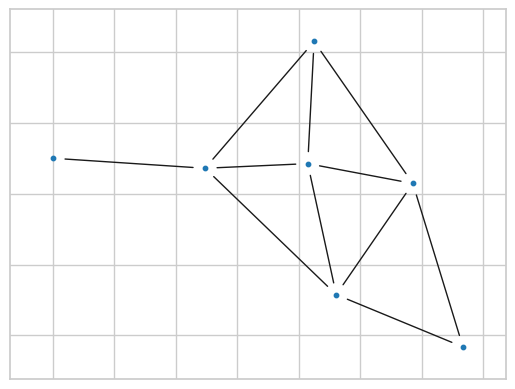

<Figure size 2000x1000 with 0 Axes>

In [16]:
import networkx as nx
import pylab as plt
G=nx.Graph();
G.add_edges_from(best_model.edges());
pos = nx.spring_layout(G);
nx.draw_networkx_nodes(G, pos, node_size = 10);
nx.draw_networkx_edges(G, pos, arrows=True);
plt.figure(5,figsize=(20,10))

In [17]:
best_model.edges()

OutEdgeView([('Brent_BZ', 'USD_Idx'), ('Brent_BZ', 'Ind_Prod'), ('WTI_CL', 'Brent_BZ'), ('WTI_CL', 'Ind_Prod'), ('USD_Idx', 'Ind_Prod'), ('CPI', 'Fed_Funds'), ('CPI', 'USD_Idx'), ('CPI', 'WTI_CL'), ('CPI', 'Brent_BZ'), ('Fed_Funds', 'USD_Idx'), ('WTI_Spot', 'WTI_CL')])